# Gem Shape Classification

In [6]:

# =========================
# Imports
# =========================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import json
import os


In [7]:

# =========================
# Config
# =========================
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 200
SOURCE_DIR = r"F:\FYP\code\dataset\GemShape"
MODEL_PATH = "gem_Shape_Classification_Model.h5"
CLASS_MAP_PATH = "gem_shapes_classes.json"


In [8]:
import os
import shutil
import random

TRAIN_DIR  = os.path.join(SOURCE_DIR, "train")
TEST_DIR   = os.path.join(SOURCE_DIR, "test")

SPLIT_RATIO = 0.8  # 80% train, 20% test

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

for class_name in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, class_name)

    if not os.path.isdir(class_path):
        continue
    if class_name in ["train", "test"]:
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    split_index = int(len(images) * SPLIT_RATIO)

    train_images = images[:split_index]
    test_images  = images[split_index:]

    os.makedirs(os.path.join(TRAIN_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, class_name), exist_ok=True)

    for img in train_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(TRAIN_DIR, class_name, img)
        )

    for img in test_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(TEST_DIR, class_name, img)
        )

print("✅ Dataset split completed")


✅ Dataset split completed


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    r"F:\FYP\code\dataset\GemShape\train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_gen = test_datagen.flow_from_directory(
    r"F:\FYP\code\dataset\GemShape\test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 1610 images belonging to 10 classes.
Found 1087 images belonging to 10 classes.


In [10]:

# =========================
# Save Class Names
# =========================
with open(CLASS_MAP_PATH, "w") as f:
    json.dump(train_gen.class_indices, f)

print("Class mapping saved:", train_gen.class_indices)


Class mapping saved: {'bar': 0, 'cushion': 1, 'heart': 2, 'marquise': 3, 'oval': 4, 'pear': 5, 'round': 6, 'square': 7, 'triangle': 8, 'uncut': 9}


In [11]:

# =========================
# CNN Model
# =========================
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:

# =========================
# Training
# =========================
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS
)


Epoch 1/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.3186 - loss: 2.0493 - val_accuracy: 0.3321 - val_loss: 1.9354
Epoch 2/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 368ms/step - accuracy: 0.3273 - loss: 1.9800 - val_accuracy: 0.3349 - val_loss: 1.9223
Epoch 3/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 367ms/step - accuracy: 0.3205 - loss: 1.9369 - val_accuracy: 0.3321 - val_loss: 1.8732
Epoch 4/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 380ms/step - accuracy: 0.3503 - loss: 1.8875 - val_accuracy: 0.3395 - val_loss: 1.7778
Epoch 5/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 353ms/step - accuracy: 0.3329 - loss: 1.8550 - val_accuracy: 0.3588 - val_loss: 1.7167
Epoch 6/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 347ms/step - accuracy: 0.3522 - loss: 1.8001 - val_accuracy: 0.4020 - val_loss: 1.6153
Epoch 7/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 351ms/step - accuracy: 0.3565 - loss: 1.7633 - val_accuracy: 0.4149 - val_loss: 1.5624
Epoch 8/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 363ms/step - accuracy: 0.3764 - loss: 1.7025 - val

34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step


<Figure size 800x600 with 0 Axes>

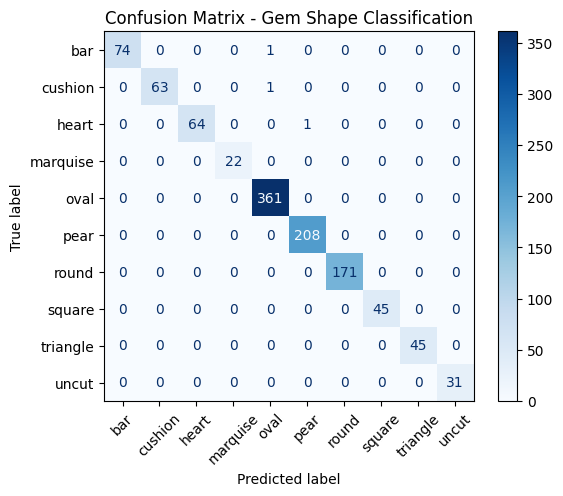

Accuracy: 99.72%

Classification Report:

              precision    recall  f1-score   support

         bar       1.00      0.99      0.99        75
     cushion       1.00      0.98      0.99        64
       heart       1.00      0.98      0.99        65
    marquise       1.00      1.00      1.00        22
        oval       0.99      1.00      1.00       361
        pear       1.00      1.00      1.00       208
       round       1.00      1.00      1.00       171
      square       1.00      1.00      1.00        45
    triangle       1.00      1.00      1.00        45
       uncut       1.00      1.00      1.00        31

    accuracy                           1.00      1087
   macro avg       1.00      1.00      1.00      1087
weighted avg       1.00      1.00      1.00      1087



In [ ]:
# =========================

# Confusion Matrix

# =========================
 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import numpy as np

import matplotlib.pyplot as plt
 
# Reset generator

test_gen.reset()
 
# Predictions

y_pred = model.predict(test_gen)
 
# Convert probabilities → class index

y_pred_classes = np.argmax(y_pred, axis=1)
 
# True labels

y_true = test_gen.classes
 
# Class labels (names)

class_labels = list(test_gen.class_indices.keys())
 
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred_classes)
 
# Plot

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)

plt.title("Confusion Matrix - Gem Shape Classification")

plt.show()
 
# Accuracy

accuracy = cm.diagonal().sum() / cm.sum()

print(f"Accuracy: {accuracy*100:.2f}%")
 
# Classification Report

print("\nClassification Report:\n")

print(classification_report(y_true, y_pred_classes, target_names=class_labels))
 

Final Training Accuracy: 89.25%
Final Validation Accuracy: 99.72%


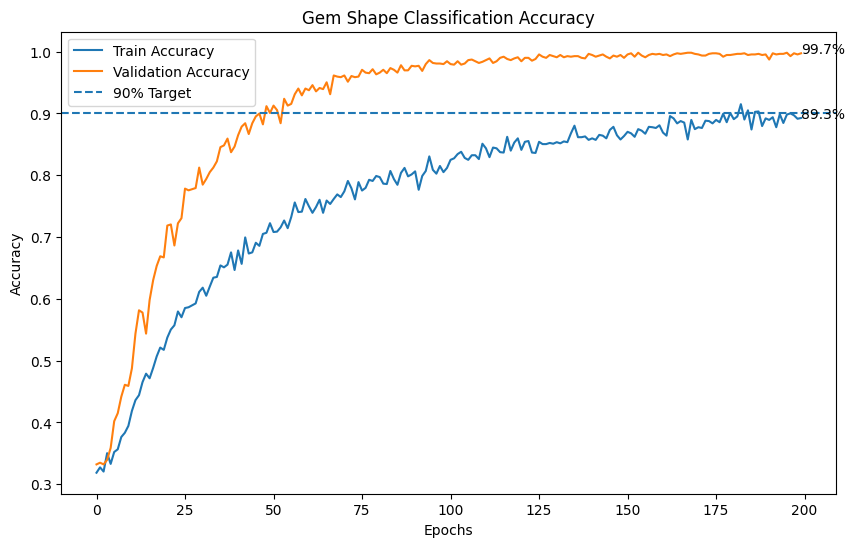

In [14]:
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Convert to percentage
final_train_acc = train_acc[-1] * 100
final_val_acc = val_acc[-1] * 100

plt.figure(figsize=(10,6))

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.axhline(0.9, linestyle='--', label='90% Target')

# Add text labels (percentage)
plt.text(len(train_acc)-1, train_acc[-1], f"{final_train_acc:.1f}%", fontsize=10)
plt.text(len(val_acc)-1, val_acc[-1], f"{final_val_acc:.1f}%", fontsize=10)

# Print values
print(f"Final Training Accuracy: {final_train_acc:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc:.2f}%")

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Gem Shape Classification Accuracy')

plt.show()

Final Training Loss: 0.2735
Final Validation Loss: 0.0235


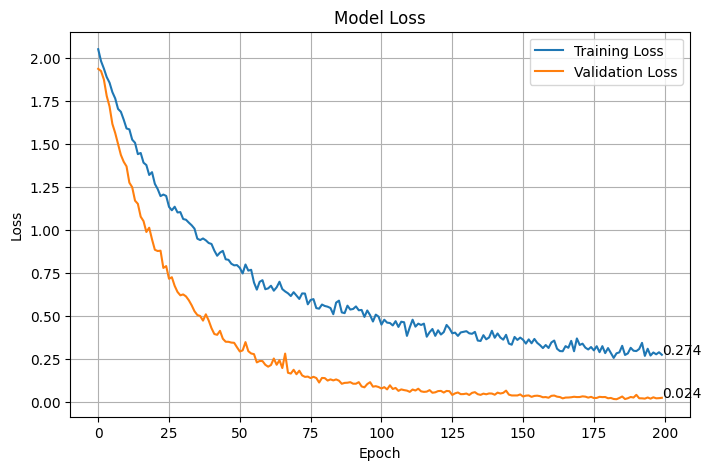

In [15]:
plt.figure(figsize=(8,5))

train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

# Add text labels (last epoch values)
plt.text(len(train_loss)-1, train_loss[-1], f"{train_loss[-1]:.3f}")
plt.text(len(val_loss)-1, val_loss[-1], f"{val_loss[-1]:.3f}")

# Print values
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.show()

In [16]:

# =========================
# Save Model
# =========================
model.save(MODEL_PATH)
print("Model saved to", MODEL_PATH)


Model saved to gem_Shape_Classification_Model.h5


In [ ]:
# import tensorflow as tf
# import numpy as np
# from PIL import Image
# import json

# # =========================
# # CONFIG
# # =========================
# IMG_SIZE = 128
# MODEL_PATH = "gem_Shape_Classification_Model.h5"
# CLASS_MAP_PATH = "gem_shapes_classes.json"
# IMAGE_PATH = r"F:\FYP\code\dataset\GemShape\test\bar\amethyst_12.jpg"

# # =========================
# # LOAD MODEL
# # =========================
# model = tf.keras.models.load_model(MODEL_PATH) 
# print("Model loaded")

# # =========================
# # LOAD CLASS NAMES
# # =========================
# with open(CLASS_MAP_PATH, "r") as f:
#     class_names = json.load(f)

# print("Classes:", class_names)

# # =========================
# # LOAD & PREPROCESS IMAGE
# # =========================
# img = Image.open(IMAGE_PATH).convert("RGB")
# img = img.resize((IMG_SIZE, IMG_SIZE))

# img_array = np.array(img).astype("float32") / 255.0
# img_array = np.expand_dims(img_array, axis=0)

# print("Image shape:", img_array.shape)

# # =========================
# # PREDICTION
# # =========================
# prediction = model.predict(img_array)
# print("Raw prediction:", prediction)

# predicted_index = int(np.argmax(prediction))

# index_to_class = {v: k for k, v in class_names.items()}
# predicted_class = index_to_class[predicted_index]

# confidence = float(np.max(prediction)) * 100

# print("FINAL RESULT")
# print("Class:", predicted_class)
# print("Confidence:", round(confidence, 2), "%")
